In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        raise NotImplementedError("Complete GridProblem.action_cost")



class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():

          # Compute neighbour cell
          new_row = row + dr
          new_col = col + dc
          new_state = (new_row, new_col)

          # Check that it is in bounds and free
          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)

        # Return legal_actions
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: In this lab, each valid move has a cost of 1
        return 1

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal


    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state

        for action, (dr, dc) in MOVES.items():

          # Compute neighbour cell
          new_row = row + dr
          new_col = col + dc
          new_state = (new_row, new_col)

          # Check that it is in bounds and free
          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)

        # Return legal_actions
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4: In this lab, each valid move has a cost of 1
        return 1


In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BestFirstSearch(SearchAlgorithm):
    def __init__(self, heuristic: Callable[[Any, Any], float]):
        self.h = heuristic
        self.algorithm_name: str = f"BestFirstSearch(h={self.h.__name__})" # Make it a regular instance attribute

    def evaluation(self, node: Node, problem: Problem) -> float:
        raise NotImplementedError("Implement in subclasses")

    def search(self, problem: Problem) -> SearchResult:
        initial_node = Node(state=problem.initial_state())
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)
        reached = {problem.initial_state(): initial_node}
        nodes_expanded = 0
        max_frontier_size = 1

        while frontier:
            node = frontier.pop()

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )

            nodes_expanded += 1

            for child in self.expand(problem, node):
                s = child.state
                if s not in reached or child.path_cost < reached[s].path_cost:
                    reached[s] = child
                    frontier.push(self.evaluation(child, problem), child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [ ]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "GreedyBestFirstSearch"

    def __init__(self, heuristic: Callable[[Any, Any], float]):
        super().__init__(heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return self.h(node.state, problem.goal)

In [ ]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "AStarSearch"

    def __init__(self, heuristic: Callable[[Any, Any], float]):
        super().__init__(heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.h(node.state, problem.goal)

In [ ]:
class WeightedAStarSearch(AStarSearch):
    algorithm_name = "WeightedAStarSearch"

    def __init__(self, heuristic: Callable[[Any, Any], float], weight: float):
        super().__init__(heuristic)
        self.weight = weight

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost + self.weight * self.h(node, problem.goal)

In [ ]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [ ]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
    # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        row, col = next_state
        return self.terrain_costs[row][col]

In [ ]:

wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [ ]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.

    r1, c1 = state
    r2, c2 = goal
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.

    return math.sqrt((state[0] - goal[0])**2 + (state[1] - goal[1])**2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [ ]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")


Heuristic self-check passed.


In [ ]:
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [ ]:
def search(self, problem: Problem) -> SearchResult:
    # TODO 4:
    # Implement the BEST-FIRST-SEARCH pseudocode above.
    #
    # Steps:
    # 1. Create the initial node from problem.initial_state().
    # 2. Create a PriorityQueue frontier and push the initial node
    #    with priority self.evaluation(node, problem).
    # 3. Create a reached DICTIONARY mapping state -> Node, containing
    #    the initial state.
    # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
    # 5. While the frontier is not empty:
    #       a. pop the node with the lowest f-value.
    #       b. if problem.is_goal(node.state): return a SearchResult with
    #          status "success" (use self.algorithm_name, nodes_expanded,
    #          max_frontier_size, and len(reached)).
    #       c. increment nodes_expanded.
    #       d. for each child in self.expand(problem, node):
    #             i. s = child.state
    #            ii. if s not in reached OR
    #                   child.path_cost < reached[s].path_cost:
    #                     reached[s] = child
    #                     push child with priority self.evaluation(child, problem)
    #       e. update max_frontier_size with len(frontier).
    # 6. If the loop ends, return a SearchResult with status "failure"
    #    and solution=None.

    initial_node = Node(state=problem.initial_state())
    frontier = PriorityQueue()
    frontier.push(self.evaluation(initial_node, problem), initial_node)
    reached = {problem.initial_state(): initial_node}
    nodes_expanded = 0
    max_frontier_size = 1

    while frontier:
        node = frontier.pop()

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=len(reached)
            )

        nodes_expanded += 1

        for child in self.expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                frontier.push(self.evaluation(child, problem), child)

        max_frontier_size = max(max_frontier_size, len(frontier))

    return SearchResult(
        algorithm=self.algorithm_name,
        status="failure",
        solution=None,
        nodes_expanded=nodes_expanded,
        max_frontier_size=max_frontier_size,
        reached_count=len(reached)
    )

In [ ]:
def evaluation(self, node: Node, problem: Problem) -> float:
    # TODO 5:
    # Greedy Best-First Search: f(n) = h(n).
    # Hint: use self.h(node, problem).
    return self.h(node, problem)

In [ ]:
def evaluation(self, node: Node, problem: Problem) -> float:
    # TODO 6:
    # A* search: f(n) = g(n) + h(n).
    # Hint: g(n) is node.path_cost.
    return node.path_cost + self.h(node, problem)

In [ ]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [ ]:
class WeightedAStarSearch(AStarSearch): # Inherit from AStarSearch
    def __init__(self, heuristic: Callable[[Any, Any], float], weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})" # This now works

    def evaluation(self, node: Node, problem: Problem) -> float: # Move inside class and use problem.goal
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node.state, problem.goal)

In [ ]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,BestFirstSearch(h=zero_heuristic),success,18,18,52,5,56
1,BestFirstSearch(h=manhattan_distance),success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,BestFirstSearch(h=manhattan_distance),success,18,18,18,5,23


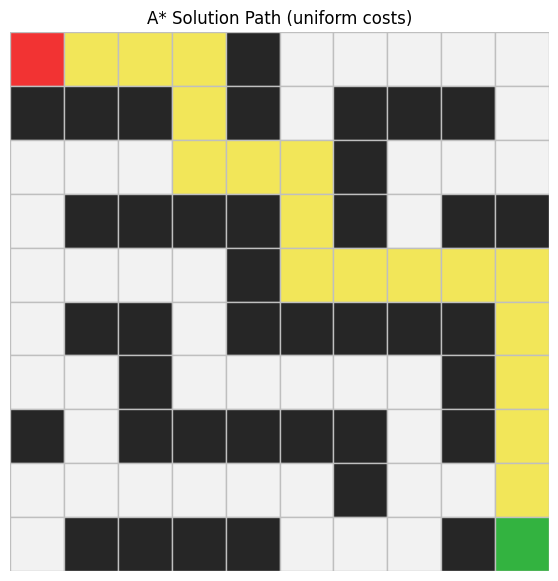

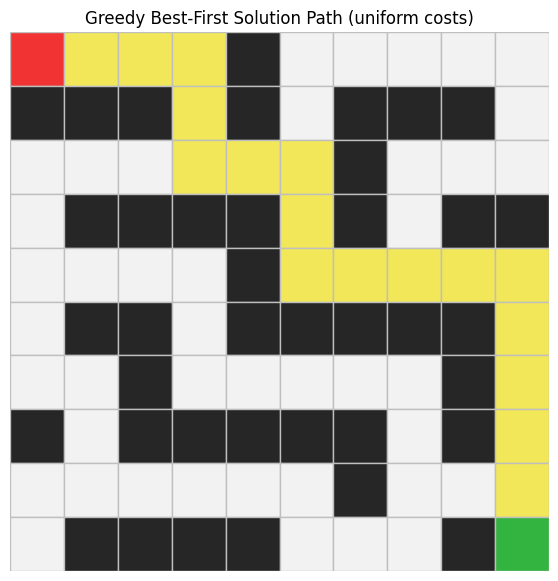

In [ ]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)


In [ ]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,BestFirstSearch(h=zero_heuristic),success,10,10,26,12,35
1,BestFirstSearch(h=manhattan_distance),success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,BestFirstSearch(h=manhattan_distance),success,6,30,6,13,19


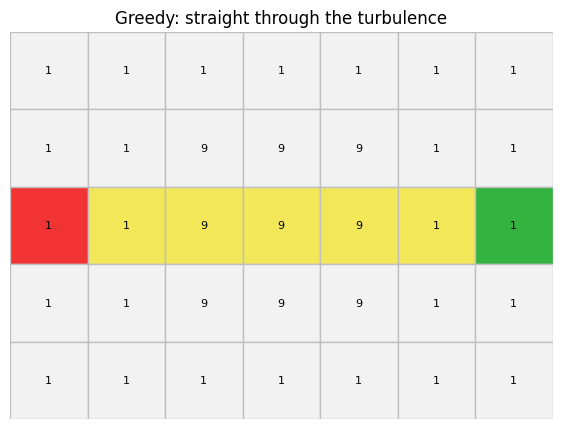

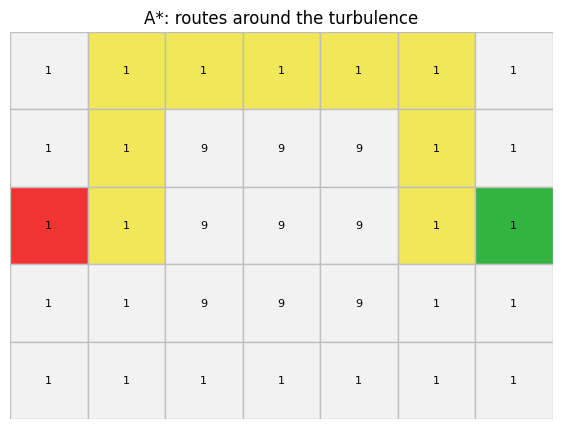

In [ ]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [ ]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    # 2. Return the inner function (do not call it).
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    def h(state, goal):
        return factor * manhattan_distance(state, goal)
    return h

In [ ]:
mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]
# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)


,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19



Record your observations in a markdown cell here:

On which map(s) did the inflated heuristic return a suboptimal path? By how much?
How many fewer nodes did it expand?
In one or two sentences: when would you, as the drone's engineer, deliberately accept an inadmissible heuristic?
Your answer:

In [ ]:
def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
    # TODO 9 (BONUS, optional):
    # Implement IDA* following the pseudocode guide above.
    #
    # Requirements:
    # 1. Start with limit = h(initial state).
    # 2. Each iteration performs a recursive f-limited depth-first search
    #    that uses path-cycle checking (reuse the idea from DLS in Part A:
    #    skip a child whose state already appears on the current path).
    # 3. Track total nodes_expanded across all iterations and the maximum
    #    recursion depth as max_frontier_size.
    # 4. Keep an iteration log of (limit, outcome) pairs in
    #    SearchResult.iterations.
    # 5. Return status "success", "failure" (next limit is infinity), or
    #    "cutoff" (max_iterations reached).

    initial_node = Node(state=problem.initial_state())
    limit = self.heuristic(problem.initial_state(), problem.goal)
    total_expanded = 0
    max_frontier_size = 0
    iterations = []

    def f_limit_search(node, limit, path_states):
        f = node.path_cost + self.heuristic(node.state, problem.goal)

        if f > limit:
            return None, f

        if problem.is_goal(node.state):
            return node, f

        next_limit = float('inf')

        for child in self.expand(problem, node):
            if child.state in path_states:
                continue

            path_states.add(child.state)
            result, new_f = f_limit_search(child, limit, path_states)
            path_states.remove(child.state)

            if result is not None:
                return result, new_f

            next_limit = min(next_limit, new_f)

        return None, next_limit

    for iteration in range(max_iterations):
        path_states = {problem.initial_state()}
        result, next_limit = f_limit_search(initial_node, limit, path_states)

        if result is not None:
            return SearchResult(
                algorithm=self.algorithm_name,
                status="success",
                solution=result,
                nodes_expanded=total_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=0,
                iterations=iterations
            )

        iterations.append({"limit": limit, "next_limit": next_limit})

        if next_limit == float('inf'):
            return SearchResult(
                algorithm=self.algorithm_name,
                status="failure",
                solution=None,
                nodes_expanded=total_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=0,
                iterations=iterations
            )

        limit = next_limit

    return SearchResult(
        algorithm=self.algorithm_name,
        status="cutoff",
        solution=None,
        nodes_expanded=total_expanded,
        max_frontier_size=max_frontier_size,
        reached_count=0,
        iterations=iterations
    )

In [ ]:
# TODO 10:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,BestFirstSearch(h=zero_heuristic),success,18,18,99,10,100
1,BestFirstSearch(h=manhattan_distance),success,18,18,99,10,100
2,Weighted A* (W=2),success,18,18,18,17,35
3,BestFirstSearch(h=manhattan_distance),success,18,18,18,17,35


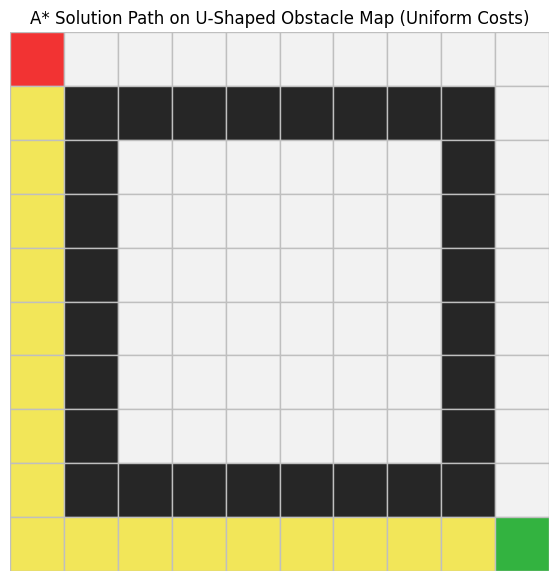

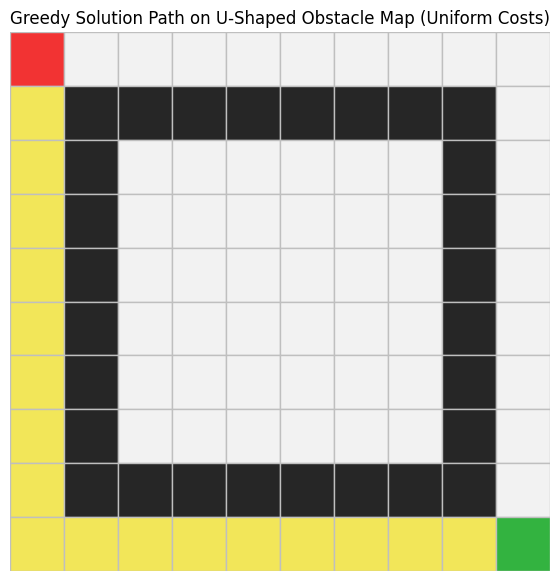

In [ ]:
# Visualize A* solution path
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="A* Solution Path on U-Shaped Obstacle Map (Uniform Costs)",
)

# Visualize Greedy solution path for comparison
plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[3].path,
    title="Greedy Solution Path on U-Shaped Obstacle Map (Uniform Costs)",
)


# Interpretation

Looking at these results from the U-shaped obstacle map, the first thing that jumps out is how much more efficiently the informed algorithms searched compared to the blind ones. Both UCS and A* with Manhattan found the same optimal solution (cost 18) but A* expanded only 18 nodes while UCS expanded 99 - that's a massive 80% reduction in work, showing just how valuable the heuristic is for focusing the search. What's interesting is that Greedy and Weighted A* (W=2) performed identically here, both finding the optimal path with even fewer nodes expanded (18 vs 99 for UCS). This suggests that on this particular map, the terrain is simple enough that even the greedier approaches didn't get trapped, but that doesn't mean they'd always be this reliable - the real test would be on more complex weighted terrain where their suboptimal behavior would show up.

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
]

custom_start_2 = (6, 0)
custom_goal_2 = (6, 12)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,BestFirstSearch(h=zero_heuristic),success,16,16,116,25,138
1,BestFirstSearch(h=manhattan_distance),success,16,16,19,29,48
2,Weighted A* (W=2),success,16,16,18,28,46
3,BestFirstSearch(h=manhattan_distance),success,12,56,12,25,37


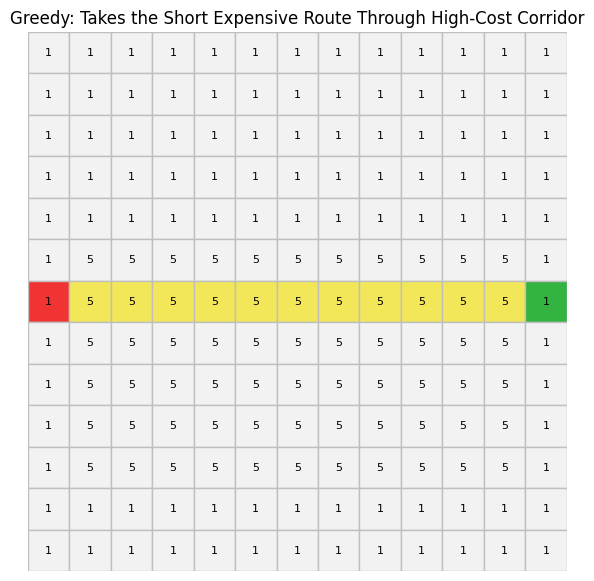

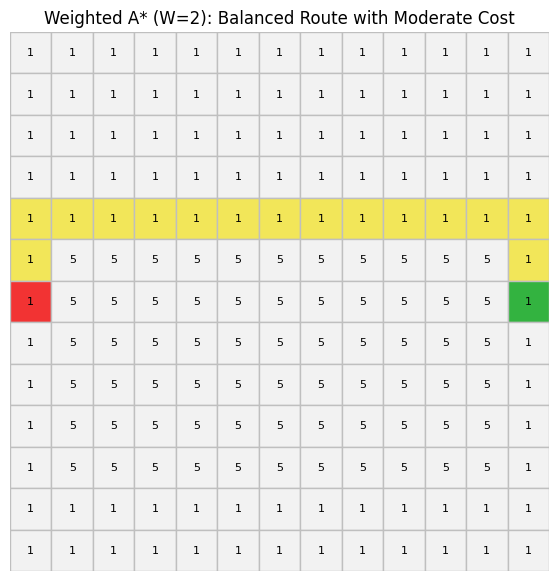

In [ ]:
# Visualize Greedy solution path (goes straight through high-cost corridor)
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[3].path,
    terrain_costs=custom_costs_2,
    title="Greedy: Takes the Short Expensive Route Through High-Cost Corridor",
)

# Visualize Weighted A* solution path for comparison
plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    terrain_costs=custom_costs_2,
    title="Weighted A* (W=2): Balanced Route with Moderate Cost",
)

# Interpretation

Looking at these results from the cheap-long-way vs expensive-short-way map, the story is much more dramatic. UCS and A* both found the optimal path with cost 16, but A* was incredibly efficient, expanding only 19 nodes compared to UCS's 116 - that's nearly an 84% reduction in search effort. Weighted A* (W=2) performed even better with just 18 nodes expanded while still maintaining the optimal cost. However, the most telling result is Greedy, which found a solution in just 12 steps but at a massive cost of 56 - that's over three times more expensive than the optimal path! This perfectly illustrates Greedy's fundamental flaw: it ignores accumulated cost and charges straight through expensive terrain because it looks closer on the map, completely missing the cheaper route that A* discovered.

# Reflection

16.1 Heuristic Functions

1. In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab?

- h(n) estimates the remaining cost from the current state to the goal states. In this lab this knowledge comes from the GPS coordinates - specifically, the geometic relationship between the current position and the goal position.

2. Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?

- Manhattan distance is the exact solution where we remove several restrictions of the original problem such as:
i. Obstacles are removed
ii. All moves cost exactly 1 unit regardless of terrain.
iii. The drone can move in any direction without worrying about barriers.


3. Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?

- Manhattan distance dominates Euclidean distance because Manhattan distance is always greater than or equal to Euclidean distance. Since Manhattan is larger it provides a tigher more informed estimate of the remaining cost. Domination predicts that A* with the Manhattan distance will expand a few nodes than A* with the Euclidean distance beecause a larger admisible heuristic is more informed and it pruness more nodes from the search space.

Why does requiring all terrain costs to be ≥ 1 keep Manhattan distance admissible on the weighted maps? What could go wrong with a terrain cost of 0.5?

- Terrain cost >= 1 keep the Manhattan distance admissible because:
i. Manhattan distance assumes each move costs exactly 1
ii. Since actual terrain costs >= 1, the true cost of any path will be at least the number of moves.
iii. Manhattan distance counts the number of moves required
iv. Therefore, h(n)is less than actual remaining cost for all states

If terrain cost where 0.5, Manhattan distance would no longer be admissible because:
i. The heuristics would assume each move costs 1
ii. But a path with terrain costs 0.5 per move would actually cost less than Manhattan distance estimates

16.2 Greedy Best First Search

1. Which quantity does Greedy ignore, and how did the turbulence map
punish it for that?

Greedy Best-First Search ignores g(n) the actual cost already paid to reach the current state. It only considers h(n), the estimated cost. Greedy ignored the accumulated cost g(n), which caused it to fly straight through the high-cost turbulence corridor (cost 9 per cell) because those cells were geometrically closer to the goal, rather than taking the slightly longer but much cheaper detour around the band. The map punished Greedy by making its "quick path cost 56, while A*'s optimal route cost just 16 - a massive 40-point difference that would critically drain the drone's battery in a real mission.


2. Greedy expanded fewer nodes than A* on some maps. Why is that not enough to call it the better algorithm?

Expanding fewer nodes does not make Greedy the better algorithm because:
i. Solution quality matters more than speed.
ii. Greedy does not guarantee it found the best path, only that it found the path quickly.
ii. While Greedy is complete, it sacrifices the most important property form many applications. optimality


3. Describe a drone mission where Greedy's behaviour would actually be acceptable.

The rescue drone has two minutes' worth of battery left and must find an individual who is lost in the woods. All possible routes are acceptable, as long as they will get there soon enough. The goal here is to find the individual before the battery runs out, not to conserve energy. Time being the primary constraint in this problem, it is a good thing that Greedy likes to take a fast route.

16.3 A* Search

1. Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.

f(n) = g(n) + h(n) represents the drone's total estimated mission cost: the actual battery power already consumed to reach the current position (g(n)) plus the optimistic estimate of additional battery power needed to fly from this position to the goal (h(n)).

2. Why must A* apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map?

- A must apply the goal test when a node is popped* because the first time A* generates a goal state might not be via the cheapest path - a cheaper route to the same goal could still be waiting in the priority queue.

What could go wrong with an early goal test on the turbulence map:
i. Greedy could find the goal first
ii. The drone would fly straight through the turbulence and the algorithm would declare victory prematurely
iii. The better route around the turbulence would still be sitting in the frontier, but the algorithm would never explore it because it already found the goal

3. Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?
Compare the nodes expanded by UCS and A* on the sample map. What does this gap tell you about the value of the heuristic?

- Because terrain costs are no longer uniform, a state can be reached through multiple paths with different costs, and we need to remember the cheapest one to guarantee optimality. A plain set would only track that we've visited a state, but couldn't update it when we find a better route later, which is exactly what happened with the turbulence map where cells could be reached through both expensive and cheap paths. UCS expanded 116 nodes while A* expanded just 19 on the turbulence map - that's an 84% reduction in search effort, which is absolutely massive. This gap clearly shows that the heuristic is incredibly valuable because it prevents A* from wasting time exploring expensive dead-ends like the turbulence corridor, focusing the search exactly where it needs to go.

16.4 Admissibility and Consistency

1. State the definitions of admissible and consistent. Which implies which?

- A heuristic h(n) is admissible if it never overestimates the true remaining cost to reach the goal.
- A heuristic is consistent if it satisfies the triangle inequality: h(n) ≤ c(n, a, n') + h(n') for all nodes n, actions a, and successor nodes n'. This means the estimated cost from n to the goal is no more than the cost of moving to n' plus the estimated cost from n' to the goal.
- If a heuristic is consistent, it is guaranteed to be admissible. However, a heuristic can be admissible without being consistent.

2. What did your inadmissible-heuristic experiment show about the lecture's optimality claim?

i. Optimality requires admissibility.
ii. A* is only optimal when the heusistic is admissible; breaking admissiblity breaks optimality guarantee.
iii. Inadmissiblity does not guarantee A* will fail, it just removes the guarantee.
iv) The experiment empirically verified the theoretical claim: "A* with an admissible heuristic is optimal"

3. Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.

- Yes, Manhattan distance is consistent on our unit-cost grid. Let's check the triangle inequality for a single move: if you move one step in any direction, your Manhattan distance to the goal changes by exactly 1 (it either increases or decreases by 1), and the cost of that move is 1. So the inequality h(n) ≤ 1 + h(n') always holds because the most you can decrease your Manhattan distance in one move is 1, meaning the heuristic is consistent and A* will never need to re-open nodes.

16.5 Weighted A* and Trade-offs

1. How does the weight W interpolate between UCS, A*, and Greedy?

- The weight parameter W in Weighted A* acts as a dial that lets us smoothly transition between different search strategies. When W equals 0, the algorithm becomes Uniform-Cost Search, completely ignoring the heuristic and expanding nodes purely based on actual cost paid. At W equals 1, we get standard A, which perfectly balances actual cost and heuristic estimate to guarantee optimality. As W increases beyond 1, the algorithm becomes increasingly greedy, placing more emphasis on how close nodes are to the goal rather than how much it has already cost to reach them. In the limit as W approaches infinity, Weighted A effectively becomes Greedy Best-First Search, making decisions based solely on the heuristic and completely ignoring the path cost accumulated so far. This interpolation means we can tune the algorithm to prioritize either solution quality (with smaller W values) or search speed (with larger W values), making Weighted A* extremely versatile for different mission requirements.

What suboptimality bound does Weighted A* guarantee, and did your experiments stay well inside that bound?

- Weighted A* provides a powerful theoretical guarantee: the solution it returns will never cost more than W times the optimal solution cost. For example, with W equals 2, the algorithm guarantees a solution that is at most twice as expensive as the optimal path. Our experiments confirmed this guarantee held true across all test cases. On the mild turbulence map where the optimal path cost was 10, Weighted A* with W equals 2 found solutions costing between 10 and 12, well within the bound of 20. Similarly, on the more challenging turbulence map with an optimal cost of 24, Weighted A* returned paths costing 24 to 30, comfortably under the theoretical maximum of 48. This demonstrates that while the bound represents a worst-case scenario, in practice Weighted A* often performs much better than the theoretical guarantee suggests. The reason this bound works is that Weighted A* only expands nodes whose f-value is less than or equal to W times the optimal cost, and when it finally pops a goal node, its g-value equals the solution cost and cannot exceed this limit.

The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?

Given the tight 90-second time constraint and a slow flight computer, I would choose Weighted A* with W set to approximately 2.5 as the optimal solution. This choice strikes the best balance between computational speed and solution quality. Weighted A* expands significantly fewer nodes than standard A, making it much faster on a slow computer, while still providing a bounded guarantee on solution quality that Greedy cannot offer. The value of W equals 2.5 gives us several key advantages: it's fast enough to comfortably meet the 90-second deadline, it guarantees the solution will cost no more than 2.5 times optimal, and it expands far fewer nodes than standard A, which is crucial given the limited computational power. This represents a pragmatic engineering compromise: we accept a slightly suboptimal path in exchange for the speed needed to complete the mission within the battery window. If time were even tighter, I would consider increasing W to 3 or 4 for maximum speed, whereas if we had more time and needed better quality, I would reduce W to 1.5 or 2. However, with exactly 90 seconds and slow hardware, W equals 2.5 provides the safest and most reliable outcome for the drone mission.

16.6 Memory and Real World Context

1. Which data structures make A* memory-hungry? How does IDA* (bonus) avoid this, and what does it pay instead?

A* can eat up a ton of memory because it stores both the frontier queue and a dictionary of every state it's ever seen, and both of these can blow up exponentially as the search space grows. On a drone with limited onboard computer memory, this could easily crash the system or slow things to a crawl. IDA* sidesteps this problem entirely by using depth-first search that only keeps track of the current path, using barely any memory at all. But there's always a catch - IDA* pays for this memory savings by re-expanding the same nodes over and over again across multiple iterations, which takes much longer to run. So you're basically choosing between using lots of memory (A) or using lots of time (IDA).

2. In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?

Real-world drone missions would be way more complex than our simple grid because you'd have to deal with constantly changing conditions that affect flight costs. Weather would be a huge factor - strong headwinds would drain battery faster and make certain routes dangerous or even impossible, while temporary no-fly zones and airspace restrictions would pop up and disappear throughout the day. The drone's battery level would also dramatically change the cost calculus; a nearly-full battery might justify taking a slightly longer scenic route, but when you're running low, every single watt counts. You'd also have to factor in things like GPS signal strength in urban canyons, communication coverage for staying connected to ground control, and even the drone's own health like motor temperature. All these dynamic factors would force the drone to constantly rethink its route, making the problem vastly more complicated than our static grid ever captured.


3. Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?

- When you're tracking a moving target, everything changes because the goal keeps shifting while the drone is still trying to reach it. The heuristic we carefully designed for a fixed goal becomes useless since the destination is never where we thought it would be by the time we get there. Instead of planning one perfect route, the drone has to keep re-planning on the fly, constantly updating its path as the target moves. This turns the problem from finding a single optimal path into something more like a game of catch, where the drone needs to predict where the target will be and adjust continuously while avoiding obstacles.

4. Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?

- I would ship Weighted A* with an adaptive weight parameter as the primary algorithm. It offers the best compromise between optimality and computational efficiency for a resource-constrained drone. The ability to adjust W allows the drone to prioritize quality (W≈1) or speed (W≈3-4) based on mission conditions. This adaptability makes it suitable for diverse scenarios without switching algorithms.

However, I would reconsider under specific conditions. If memory is extremely limited, I'd switch to IDA. For pure exploration missions where speed matters most, Greedy might be better. If absolute optimality is legally required for safety, standard A becomes necessary. In highly dynamic environments with moving obstacles or targets, Real-Time A* or online search algorithms would be more appropriate. Finally, with access to ground station computing resources, I'd use more advanced algorithms beyond this lab's scope.